# Customer Support Ticket Intelligence Platform
## Phase 2: Exploratory Data Analysis (EDA)

**Goal**: Visually explore the CFPB consumer complaints dataset to understand class distributions, text characteristics, noise patterns, and semantic overlaps — generating evidence to validate or revise preprocessing decisions in `03_text_preprocessing.ipynb`.

**Key questions this notebook answers**:
1. How severe is the class imbalance? Which categories will struggle?
2. How does text length vary across categories? Is `MAX_LEN=256` appropriate?
3. How prevalent are XXXX redaction tokens? Do they help or hurt?
4. Which category pairs have the highest semantic overlap (hardest to distinguish)?
5. What words are most discriminative per category?

> **Note**: Data loading and deduplication were done in `01_project_planning.ipynb`. This notebook works with the pre-built `df_sample.csv` (200,000 rows).

---
### Section 1: Setup & Load Dataset

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/df_sample.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Nulls: {df.isnull().sum().to_dict()}')
print(f'Unique categories: {df["category"].nunique()}')
df.head(3)

Shape: (200000, 2)
Columns: ['issue_description', 'category']
Nulls: {'issue_description': 0, 'category': 0}
Unique categories: 18


,issue_description,category
0,I paid my debt and when i was getting the amou...,Debt collection
1,I have had an ongoing problem and now will res...,"Credit reporting, credit repair services, or o..."
2,Complaint Details I filled out an application ...,Mortgage


---
### Section 2: Class Distribution & Imbalance Analysis

Class imbalance directly impacts deep learning training. Standard `CrossEntropyLoss` treats all classes equally, causing the model to become biased toward majority classes and ignore minority ones. Understanding the severity of imbalance informs our choice of:
- **Class-weighted loss** (penalise majority class errors less, minority more)
- **Evaluation metric** (macro F1 instead of accuracy, since accuracy is misleading when 45% of data belongs to 2 classes)

In [4]:
# ── Class counts ──────────────────────────────────────────────────────────────
class_counts = df['category'].value_counts()
class_pcts = (class_counts / len(df) * 100).round(2)

# ── Imbalance metrics ─────────────────────────────────────────────────────────
imbalance_ratio = class_counts.max() / class_counts.min()
minority_classes = class_pcts[class_pcts < 1.0]

print('═' * 60)
print('  CLASS IMBALANCE METRICS')
print('═' * 60)
print(f'  Largest class  : {class_counts.idxmax()} ({class_counts.max():,})')
print(f'  Smallest class : {class_counts.idxmin()} ({class_counts.min():,})')
print(f'  Imbalance ratio: {imbalance_ratio:,.0f}x')
print(f'  Minority classes (< 1%): {len(minority_classes)}')
for cat, pct in minority_classes.items():
    print(f'    → {cat}: {pct}%')

════════════════════════════════════════════════════════════
  CLASS IMBALANCE METRICS
════════════════════════════════════════════════════════════
  Largest class  : Debt collection (45,934)
  Smallest class : Virtual currency (8)
  Imbalance ratio: 5,742x
  Minority classes (< 1%): 5
    → Payday loan: 0.47%
    → Money transfers: 0.41%
    → Prepaid card: 0.39%
    → Other financial service: 0.08%
    → Virtual currency: 0.0%


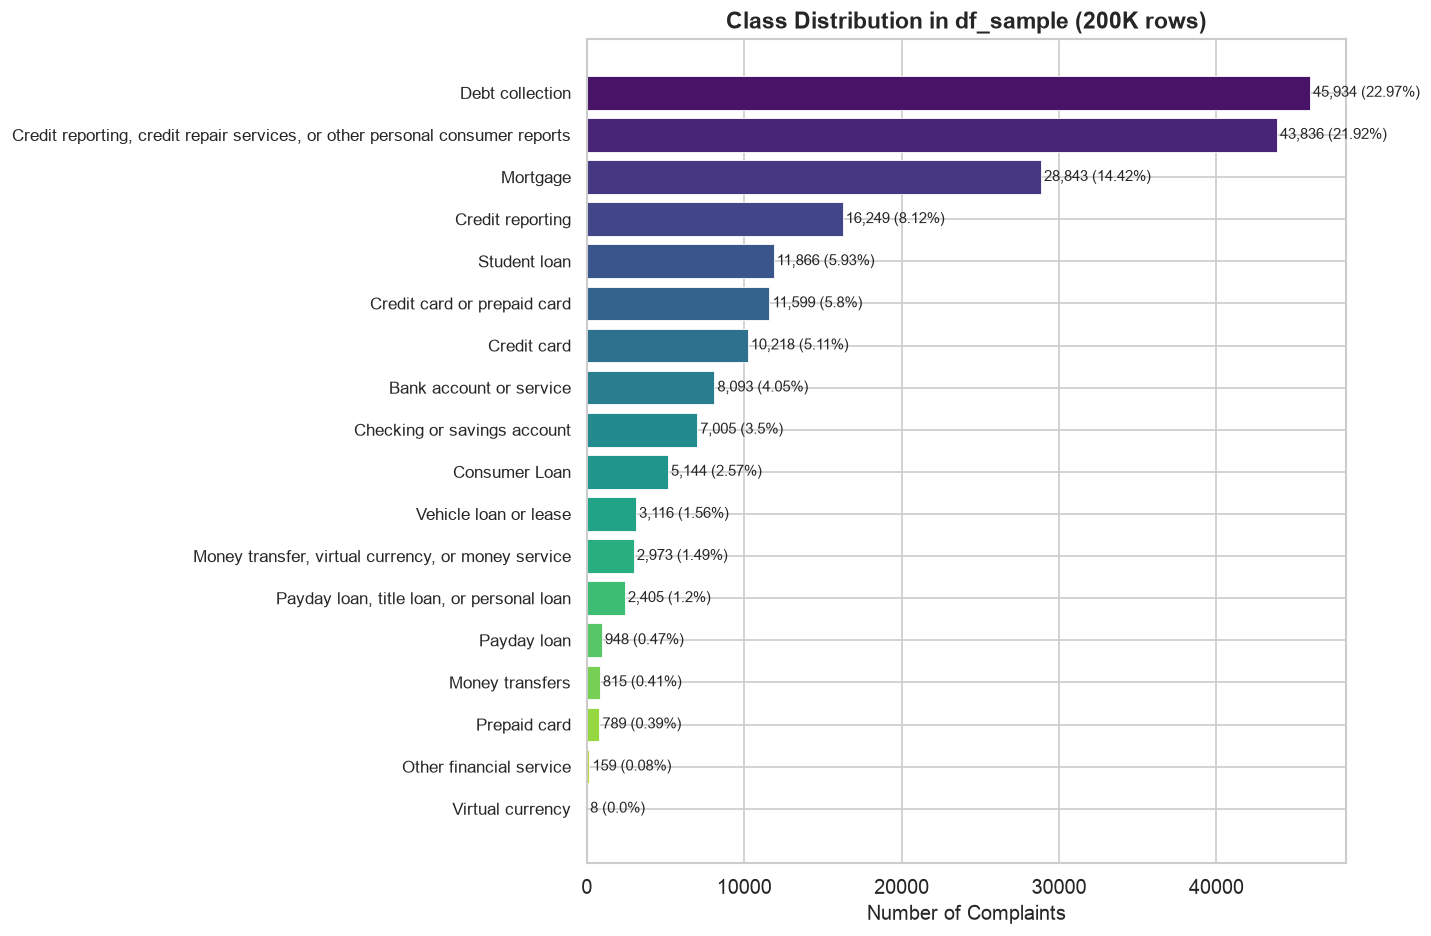

✅ Saved: outputs/eda_class_distribution.png


In [5]:
# ── Horizontal bar chart: Class distribution ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette('viridis', n_colors=len(class_counts))
bars = ax.barh(
    range(len(class_counts)),
    class_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=0.5,
)
ax.set_yticks(range(len(class_counts)))
ax.set_yticklabels(class_counts.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Number of Complaints')
ax.set_title('Class Distribution in df_sample (200K rows)', fontweight='bold')

# Add percentage labels
for i, (cnt, pct) in enumerate(zip(class_counts.values, class_pcts.values)):
    ax.text(cnt + 200, i, f'{cnt:,} ({pct}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/eda_class_distribution.png')

---
### Section 3: Text Length Distribution (Characters & Tokens)

Understanding the distribution of text lengths is critical for choosing `MAX_LEN` — the sequence length cutoff for our PyTorch datasets. Every sequence is padded or truncated to this fixed length:
- **Too short** → excessive truncation, losing important complaint details
- **Too long** → excessive padding, wasting memory and compute (RNN hidden states process padding tokens uselessly)

In [6]:
from src.preprocessing import clean_text, tokenize
from tqdm import tqdm

# ── Compute token lengths (using our actual preprocessing pipeline) ──────────
print('Tokenising 200,000 complaints with src.preprocessing pipeline...')
token_lengths = np.array([
    len(tokenize(clean_text(text)))
    for text in tqdm(df['issue_description'], unit='doc')
])
df['token_length'] = token_lengths

# ── Also compute raw character lengths ───────────────────────────────────────
df['char_length'] = df['issue_description'].astype(str).apply(len)

# ── Summary statistics ───────────────────────────────────────────────────────
print('\nToken length statistics (after clean_text + tokenize):')
for label, val in [
    ('Min',      token_lengths.min()),
    ('25th pct', np.percentile(token_lengths, 25)),
    ('Median',   np.median(token_lengths)),
    ('Mean',     token_lengths.mean()),
    ('75th pct', np.percentile(token_lengths, 75)),
    ('90th pct', np.percentile(token_lengths, 90)),
    ('95th pct', np.percentile(token_lengths, 95)),
    ('99th pct', np.percentile(token_lengths, 99)),
    ('Max',      token_lengths.max()),
]:
    print(f'  {label:<12}: {val:>8.1f}')

Tokenising 200,000 complaints with src.preprocessing pipeline...


100%|██████████| 200000/200000 [00:46<00:00, 4267.51doc/s]



Token length statistics (after clean_text + tokenize):
  Min         :      1.0
  25th pct    :     76.0
  Median      :    142.0
  Mean        :    203.6
  75th pct    :    258.0
  90th pct    :    438.0
  95th pct    :    596.0
  99th pct    :    935.0
  Max         :   6491.0


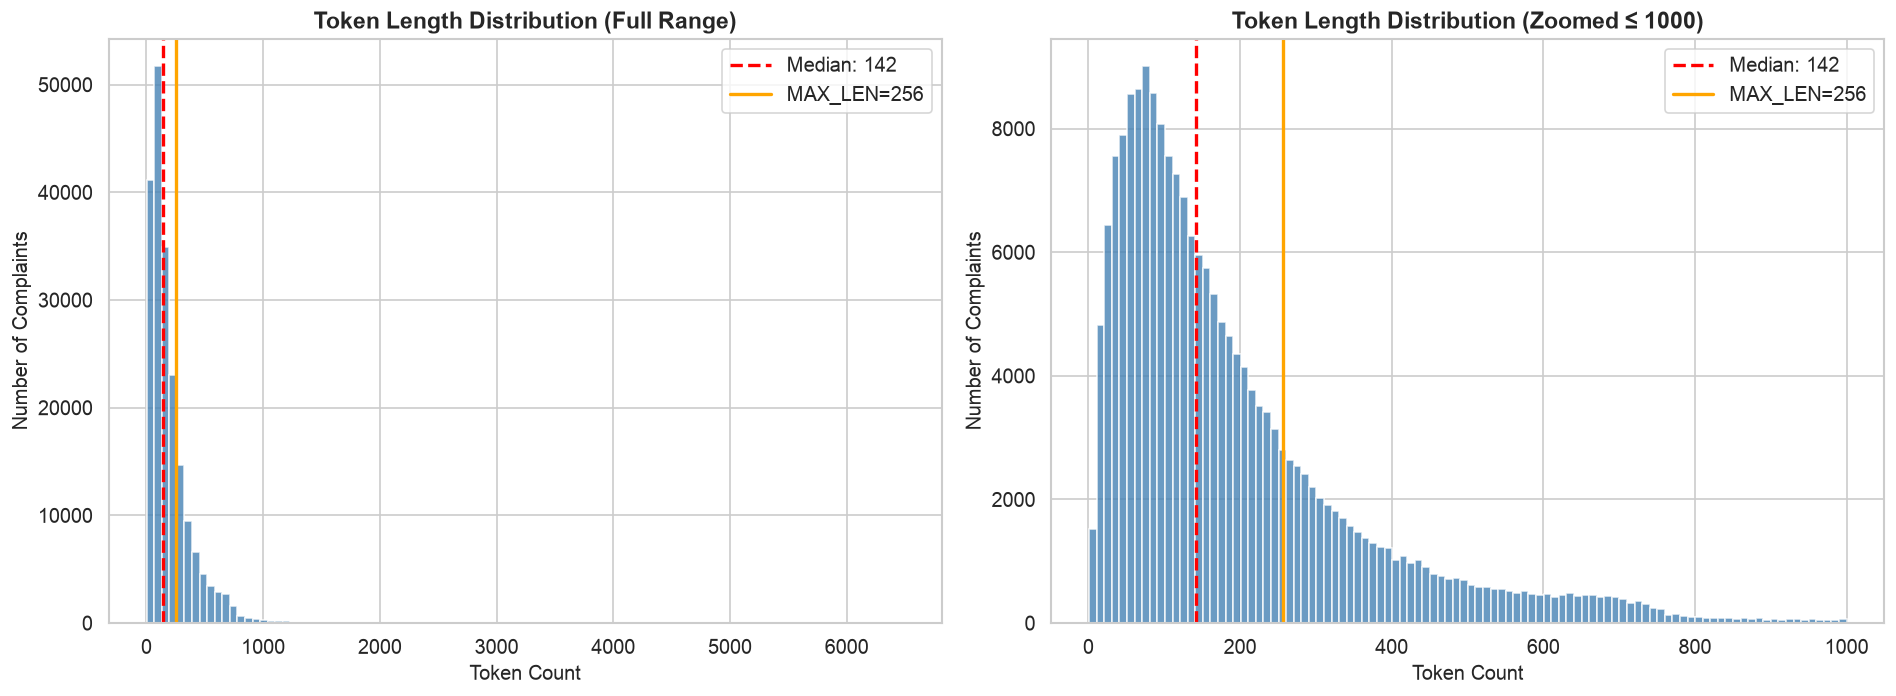

✅ Saved: outputs/eda_token_length_distribution.png


In [7]:
# ── Histogram: Token length distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Full distribution
ax = axes[0]
ax.hist(token_lengths, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.median(token_lengths), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(token_lengths):.0f}')
ax.axvline(256, color='orange', linestyle='-', linewidth=2, label='MAX_LEN=256')
ax.set_xlabel('Token Count')
ax.set_ylabel('Number of Complaints')
ax.set_title('Token Length Distribution (Full Range)', fontweight='bold')
ax.legend()

# Right: Zoomed to 0-1000 (where most data lives)
ax = axes[1]
ax.hist(token_lengths[token_lengths <= 1000], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(np.median(token_lengths), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(token_lengths):.0f}')
ax.axvline(256, color='orange', linestyle='-', linewidth=2, label='MAX_LEN=256')
ax.set_xlabel('Token Count')
ax.set_ylabel('Number of Complaints')
ax.set_title('Token Length Distribution (Zoomed ≤ 1000)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/eda_token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/eda_token_length_distribution.png')

In [8]:
# ── Truncation impact at various MAX_LEN thresholds ──────────────────────────
print('Truncation impact analysis:')
print(f'  {"MAX_LEN":<10} {"% NOT truncated":<20} {"% Truncated":<15} {"Truncated count"}')
print(f'  {"-"*60}')
for ml in [64, 128, 192, 256, 384, 512]:
    pct_kept = (token_lengths <= ml).mean() * 100
    pct_trunc = 100 - pct_kept
    n_trunc = (token_lengths > ml).sum()
    marker = ' ← current' if ml == 256 else ''
    print(f'  {ml:<10} {pct_kept:>6.1f}%              {pct_trunc:>5.1f}%          {n_trunc:>7,}{marker}')

Truncation impact analysis:
  MAX_LEN    % NOT truncated      % Truncated     Truncated count
  ------------------------------------------------------------
  64           20.1%               79.9%          159,733
  128          45.8%               54.2%          108,489
  192          63.3%               36.7%           73,490
  256          74.8%               25.2%           50,371 ← current
  384          87.1%               12.9%           25,811
  512          92.8%                7.2%           14,409


---
### Section 4: Text Length by Category

Different complaint types may have systematically different text lengths. If one category's texts are overwhelmingly truncated at `MAX_LEN=256` while another's are barely affected, the model loses disproportionate information from that category — creating an implicit bias.

/tmp/ipykernel_309272/868259643.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


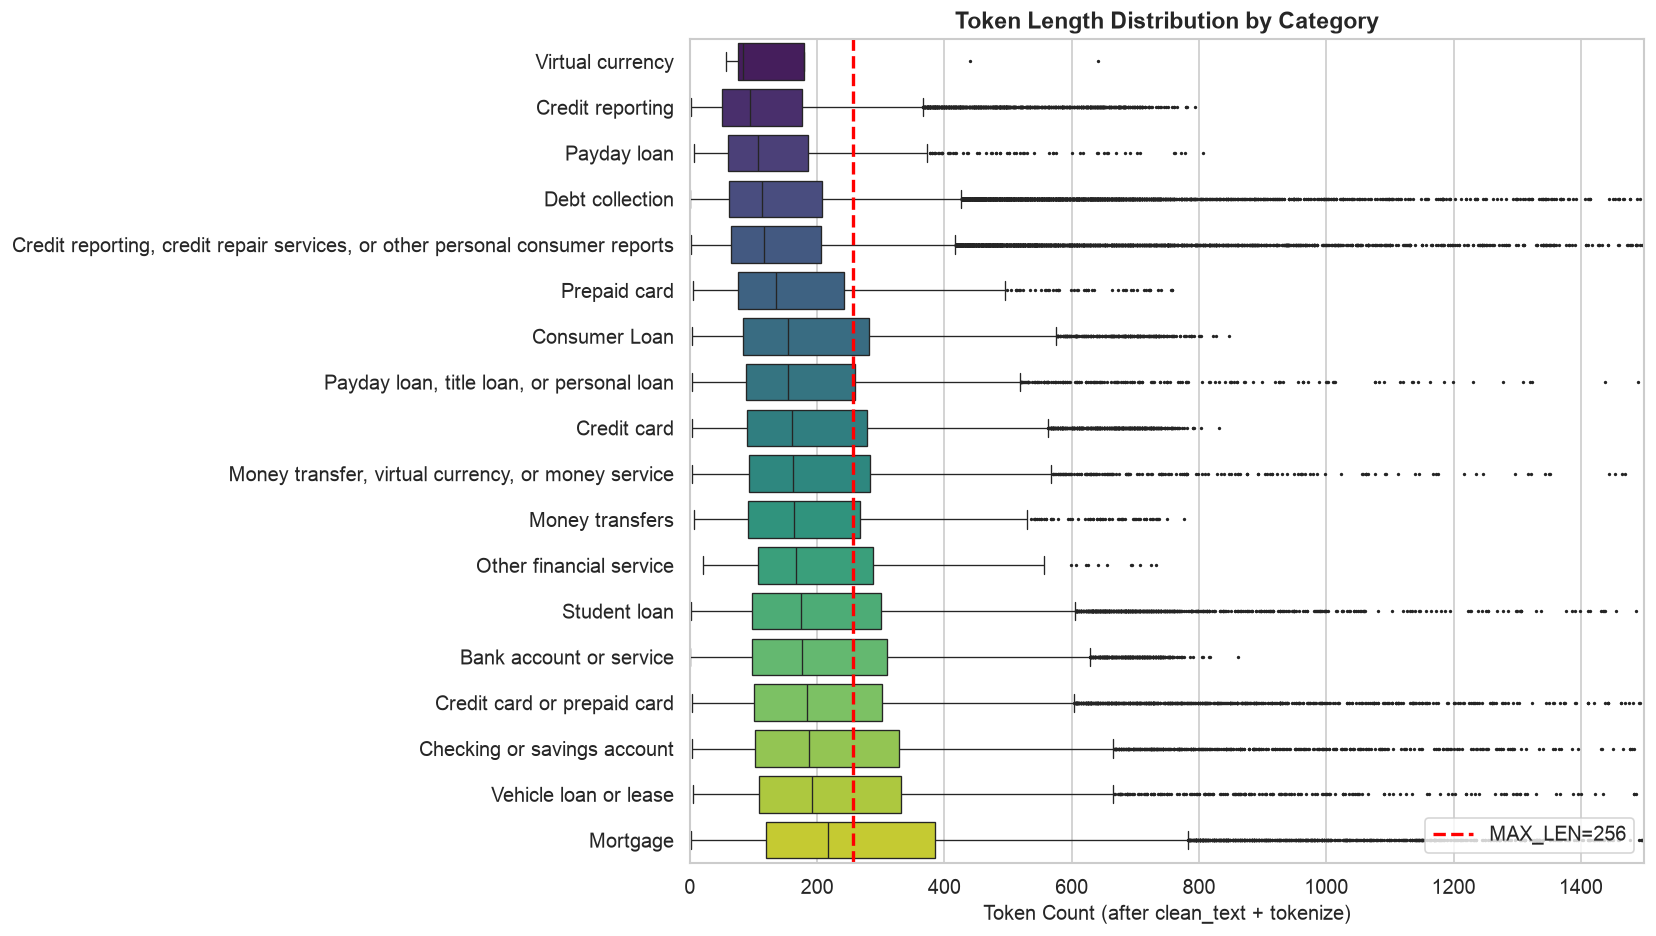

✅ Saved: outputs/eda_token_length_by_category.png


In [9]:
# ── Box plot: Token length by category ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

# Sort categories by median token length
cat_order = df.groupby('category')['token_length'].median().sort_values(ascending=True).index

sns.boxplot(
    data=df, y='category', x='token_length',
    order=cat_order, palette='viridis',
    fliersize=1, linewidth=0.8, ax=ax,
)
ax.axvline(256, color='red', linestyle='--', linewidth=2, label='MAX_LEN=256')
ax.set_xlabel('Token Count (after clean_text + tokenize)')
ax.set_ylabel('')
ax.set_title('Token Length Distribution by Category', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 1500)

plt.tight_layout()
plt.savefig('../outputs/eda_token_length_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/eda_token_length_by_category.png')

In [10]:
# ── Per-category truncation rate at MAX_LEN=256 ──────────────────────────────
MAX_LEN = 256
trunc_rates = (
    df.groupby('category')['token_length']
    .apply(lambda x: (x > MAX_LEN).mean() * 100)
    .sort_values(ascending=False)
)

print(f'Per-category truncation rate at MAX_LEN={MAX_LEN}:')
print(f'  {"Category":<65} {"Truncated %":>10}')
print(f'  {"-"*75}')
for cat, rate in trunc_rates.items():
    flag = ' ⚠️' if rate > 40 else ''
    print(f'  {cat:<65} {rate:>8.1f}%{flag}')

print(f'\n  Overall truncation rate: {(token_lengths > MAX_LEN).mean()*100:.1f}%')

Per-category truncation rate at MAX_LEN=256:
  Category                                                          Truncated %
  ---------------------------------------------------------------------------
  Mortgage                                                              41.9% ⚠️
  Vehicle loan or lease                                                 36.1%
  Checking or savings account                                           35.1%
  Bank account or service                                               32.8%
  Credit card or prepaid card                                           32.7%
  Student loan                                                          31.8%
  Other financial service                                               30.2%
  Money transfer, virtual currency, or money service                    29.0%
  Consumer Loan                                                         28.8%
  Credit card                                                           28.5%
  Money transf

---
### Section 5: Text Noise & Redaction Pattern Audit

CFPB complaints are legally redacted — personal information (names, dates, account numbers, amounts) is replaced with `XXXX` or `XX/XX/XXXX`. These anonymisation markers are extremely frequent in the corpus and may:
- **Help**: Serve as implicit markers for financial-specific content (amount mentions, date mentions)
- **Hurt**: Dilute the semantic signal by replacing discriminative information with uniform noise

XXXX Redaction Token Analysis:
  Complaints with ≥1 XXXX token: 172,509 (86.3%)
  Mean XXXX count per complaint : 13.5
  Median XXXX count             : 7
  Max XXXX count                : 2311


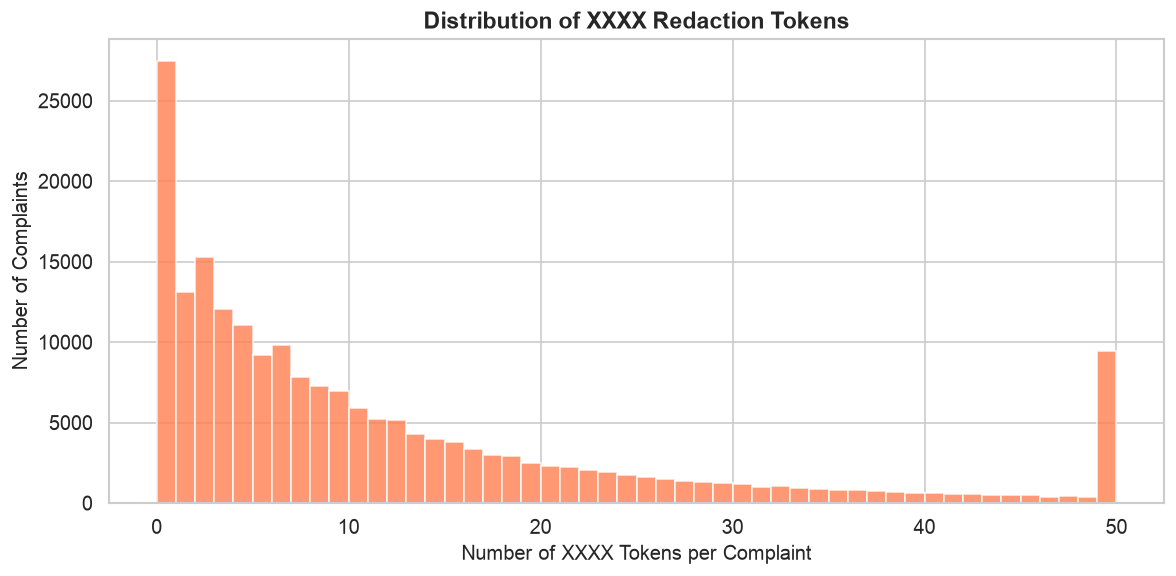

✅ Saved: outputs/eda_xxxx_distribution.png


In [11]:
import re

# ── Count XXXX occurrences per complaint ─────────────────────────────────────
xxxx_pattern = re.compile(r'\bX{2,}\b', re.IGNORECASE)
df['xxxx_count'] = df['issue_description'].astype(str).apply(
    lambda t: len(xxxx_pattern.findall(t))
)

print('XXXX Redaction Token Analysis:')
print(f'  Complaints with ≥1 XXXX token: {(df["xxxx_count"] > 0).sum():,} ({(df["xxxx_count"] > 0).mean()*100:.1f}%)')
print(f'  Mean XXXX count per complaint : {df["xxxx_count"].mean():.1f}')
print(f'  Median XXXX count             : {df["xxxx_count"].median():.0f}')
print(f'  Max XXXX count                : {df["xxxx_count"].max()}')

# ── Histogram ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['xxxx_count'].clip(upper=50), bins=50, color='coral', edgecolor='white', alpha=0.8)
ax.set_xlabel('Number of XXXX Tokens per Complaint')
ax.set_ylabel('Number of Complaints')
ax.set_title('Distribution of XXXX Redaction Tokens', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_xxxx_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/eda_xxxx_distribution.png')

In [12]:
# ── Ultra-short text audit ────────────────────────────────────────────────────
SHORT_THRESHOLD = 10
short_texts = df[df['token_length'] < SHORT_THRESHOLD]

print(f'Ultra-short texts (< {SHORT_THRESHOLD} tokens): {len(short_texts):,} ({len(short_texts)/len(df)*100:.2f}%)')
print(f'\nCategory breakdown of ultra-short texts:')
for cat, cnt in short_texts['category'].value_counts().items():
    print(f'  {cat:<60} {cnt:>5}')

print(f'\n10 sample ultra-short complaints:')
print('─' * 80)
for _, row in short_texts.sample(min(10, len(short_texts)), random_state=42).iterrows():
    print(f'  [{row["category"]}]')
    print(f'  Text: "{row["issue_description"][:200]}"')
    print(f'  Tokens: {row["token_length"]}')
    print('─' * 80)

Ultra-short texts (< 10 tokens): 1,178 (0.59%)

Category breakdown of ultra-short texts:
  Debt collection                                                376
  Credit reporting, credit repair services, or other personal consumer reports   335
  Credit reporting                                               208
  Mortgage                                                        45
  Student loan                                                    41
  Credit card                                                     40
  Consumer Loan                                                   26
  Checking or savings account                                     26
  Credit card or prepaid card                                     21
  Bank account or service                                         17
  Money transfer, virtual currency, or money service              14
  Payday loan, title loan, or personal loan                       13
  Vehicle loan or lease                                            

---
### Section 6: Category Semantic Overlap Investigation

Several CFPB categories share near-identical names and likely overlapping complaint language. These pairs represent the **hardest classification challenge** — the model must learn subtle semantic differences rather than relying on obvious keyword cues.

**Pairs to investigate:**
1. "Credit reporting" vs "Credit reporting, credit repair services, or other personal consumer reports"
2. "Credit card" vs "Credit card or prepaid card"
3. "Payday loan" vs "Payday loan, title loan, or personal loan"
4. "Money transfers" vs "Money transfer, virtual currency, or money service"
5. "Bank account or service" vs "Checking or savings account" 

In [13]:
from src.preprocessing import clean_text, tokenize

def get_top_words(category, n=100):
    """Get the top-n most common words for a given category after cleaning."""
    texts = df[df['category'] == category]['issue_description']
    words = []
    for text in texts.sample(min(5000, len(texts)), random_state=42):
        words.extend(tokenize(clean_text(str(text))))
    return Counter(words).most_common(n)

def jaccard_similarity(set_a, set_b):
    """Compute Jaccard similarity between two word sets."""
    intersection = set_a & set_b
    union = set_a | set_b
    return len(intersection) / len(union) if union else 0.0

# ── Define overlap pairs to investigate ──────────────────────────────────────
overlap_pairs = [
    ('Credit reporting', 'Credit reporting, credit repair services, or other personal consumer reports'),
    ('Credit card', 'Credit card or prepaid card'),
    ('Payday loan', 'Payday loan, title loan, or personal loan'),
    ('Money transfers', 'Money transfer, virtual currency, or money service'),
    ('Bank account or service', 'Checking or savings account'),
]

print('═' * 70)
print('  CATEGORY SEMANTIC OVERLAP ANALYSIS')
print('═' * 70)

TOP_N = 50
for cat_a, cat_b in overlap_pairs:
    words_a = set(w for w, _ in get_top_words(cat_a, TOP_N))
    words_b = set(w for w, _ in get_top_words(cat_b, TOP_N))
    
    jaccard = jaccard_similarity(words_a, words_b)
    shared = words_a & words_b
    unique_a = words_a - words_b
    unique_b = words_b - words_a
    
    # Short labels for display
    label_a = cat_a[:40]
    label_b = cat_b[:40]
    
    print(f'\n  {label_a} vs {label_b}')
    print(f'  Jaccard similarity (top-{TOP_N} words): {jaccard:.2%}')
    print(f'  Shared words ({len(shared)}): {", ".join(sorted(list(shared))[:15])}...')
    print(f'  Unique to A  ({len(unique_a)}): {", ".join(sorted(list(unique_a))[:10])}...')
    print(f'  Unique to B  ({len(unique_b)}): {", ".join(sorted(list(unique_b))[:10])}...')
    print(f'  {"─"*68}')

══════════════════════════════════════════════════════════════════════
  CATEGORY SEMANTIC OVERLAP ANALYSIS
══════════════════════════════════════════════════════════════════════

  Credit reporting vs Credit reporting, credit repair services
  Jaccard similarity (top-50 words): 92.31%
  Shared words (48): a, account, accounts, all, am, an, and, any, are, as, be, been, but, by, credit...
  Unique to A  (2): do, experian...
  Unique to B  (2): 00, company...
  ────────────────────────────────────────────────────────────────────

  Credit card vs Credit card or prepaid card
  Jaccard similarity (top-50 words): 88.68%
  Shared words (47): 00, a, account, an, and, as, at, bank, be, been, but, by, called, card, credit...
  Unique to A  (3): balance, do, n't...
  Unique to B  (3): one, which, you...
  ────────────────────────────────────────────────────────────────────

  Payday loan vs Payday loan, title loan, or personal loa
  Jaccard similarity (top-50 words): 75.44%
  Shared words (43): 

---
### Section 7: Top Discriminative Words by Category

Which words are most characteristic of each category? This analysis helps us understand:
- What **signal** the model will learn from (category-specific vocabulary)
- What **noise** exists (stopwords like "the", "i", "was" appear uniformly across all categories)
- Whether our vocabulary and preprocessing pipeline preserves discriminative tokens

In [14]:
# ── Compute top-10 words per category (excluding common stopwords) ────────────
STOPWORDS = {'the', 'i', 'to', 'and', 'a', 'of', 'my', 'was', 'that', 'is',
             'in', 'on', 'for', 'it', 'have', 'not', 'they', 'this', 'me',
             'with', 'had', 'but', 'are', 'be', 'were', 'been', 'has', 'from',
             'an', 'at', 'or', 'would', 'which', 'so', 'we', 'there', 'their',
             'them', 'will', 'do', 'did', 'no', 'if', 'as', 'also', 'can',
             'about', 'when', 'all', 'he', 'she', 'her', 'his', 'you', 'your',
             'xxxx', 'xx'}

# Select 6 representative categories (mix of large and small)
selected_cats = [
    'Debt collection',
    'Mortgage',
    'Student loan',
    'Credit card',
    'Checking or savings account',
    'Vehicle loan or lease',
]

print('Top-10 discriminative words per category (stopwords removed):')
print('═' * 70)

cat_top_words = {}
for cat in selected_cats:
    top = get_top_words(cat, n=200)
    filtered = [(w, c) for w, c in top if w not in STOPWORDS][:10]
    cat_top_words[cat] = filtered
    
    print(f'\n  [{cat}]')
    for rank, (word, count) in enumerate(filtered, 1):
        print(f'    {rank:>2}. {word:<20} {count:>6,}')

Top-10 discriminative words per category (stopwords removed):
══════════════════════════════════════════════════════════════════════

  [Debt collection]
     1. debt                  8,330
     2. credit                6,398
     3. account               4,816
     4. company               3,510
     5. collection            3,379
     6. 00                    3,363
     7. by                    3,118
     8. any                   2,941
     9. report                2,939
    10. received              2,687

  [Mortgage]
     1. loan                 10,486
     2. mortgage             10,256
     3. payment               7,409
     4. 00                    7,145
     5. our                   6,355
     6. by                    5,643
     7. home                  5,127
     8. payments              4,449
     9. bank                  4,336
    10. told                  4,087

  [Student loan]
     1. loan                 11,656
     2. payment               8,077
     3. loans         

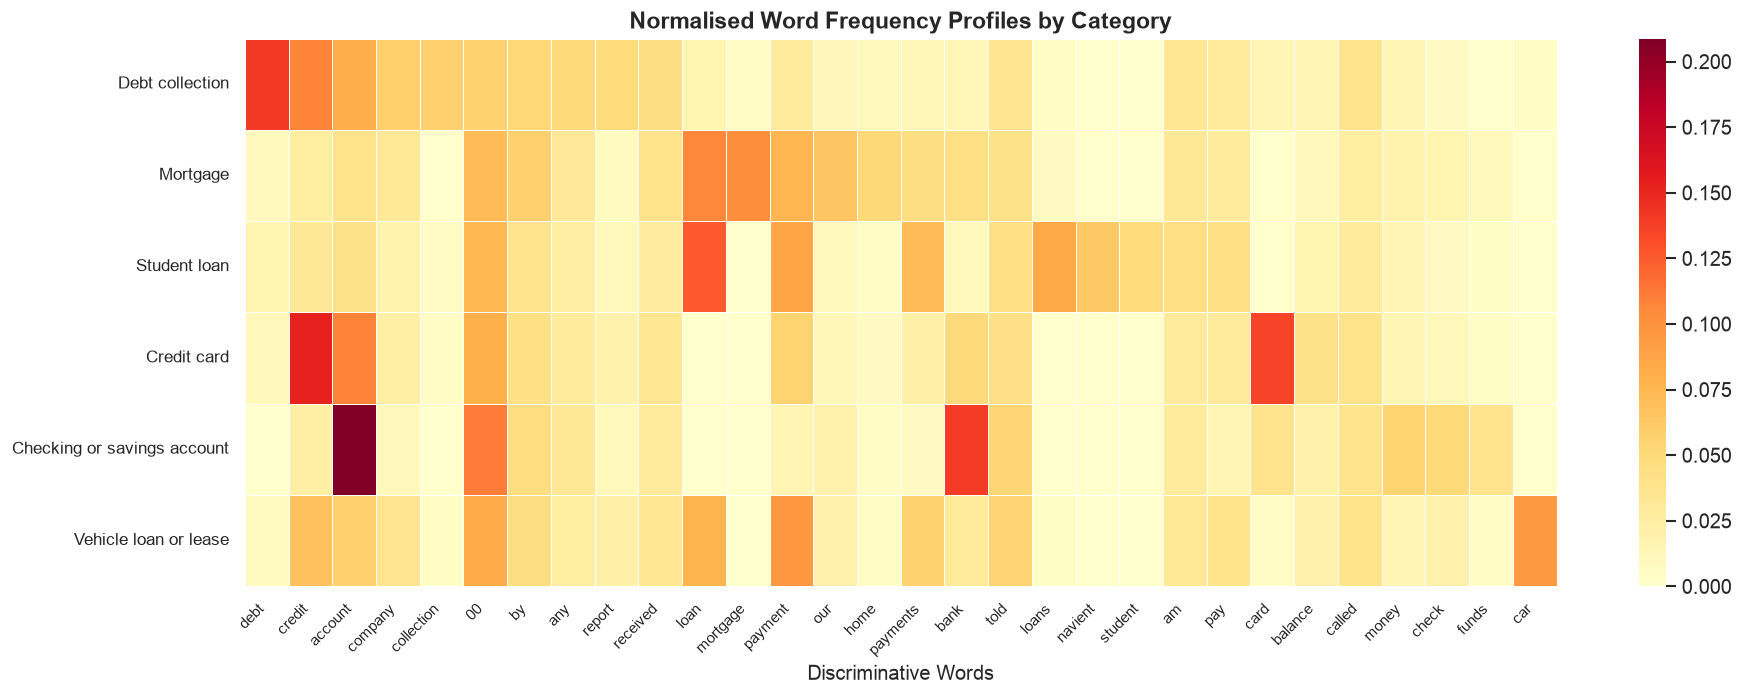

✅ Saved: outputs/eda_word_frequency_heatmap.png


In [15]:
# ── Heatmap: Word frequency profiles across categories ───────────────────────
# Collect all unique discriminative words from selected categories
all_disc_words = []
for cat in selected_cats:
    all_disc_words.extend([w for w, _ in cat_top_words[cat]])
unique_words = list(dict.fromkeys(all_disc_words))[:30]  # top-30 unique words

# Build frequency matrix
freq_matrix = pd.DataFrame(0, index=selected_cats, columns=unique_words)
for cat in selected_cats:
    word_dict = dict(get_top_words(cat, n=500))
    for word in unique_words:
        freq_matrix.loc[cat, word] = word_dict.get(word, 0)

# Normalise per category (so we compare relative frequencies)
freq_norm = freq_matrix.div(freq_matrix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    freq_norm, annot=False, cmap='YlOrRd', linewidths=0.5,
    xticklabels=True, yticklabels=True, ax=ax,
)
ax.set_title('Normalised Word Frequency Profiles by Category', fontweight='bold')
ax.set_xlabel('Discriminative Words')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/eda_word_frequency_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/eda_word_frequency_heatmap.png')

---
### Section 8: EDA Summary & Preprocessing Review

This section consolidates all EDA findings and evaluates whether they warrant any changes to the preprocessing decisions in `03_text_preprocessing.ipynb`.

In [16]:
# ── Print structured summary card ─────────────────────────────────────────────
print('╔' + '═'*68 + '╗')
print('║' + '  EDA SUMMARY CARD'.center(68) + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Total samples          : {len(df):>10,}' + ' '*30 + '║')
print(f'║  Number of classes      : {df["category"].nunique():>10}' + ' '*30 + '║')
print(f'║  Imbalance ratio        : {imbalance_ratio:>10,.0f}x' + ' '*29 + '║')
print(f'║  Minority classes (<1%) : {len(minority_classes):>10}' + ' '*30 + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Median token length    : {np.median(token_lengths):>10.0f}' + ' '*30 + '║')
print(f'║  Mean token length      : {token_lengths.mean():>10.1f}' + ' '*30 + '║')
print(f'║  Truncation at MAX=256  : {(token_lengths > 256).mean()*100:>9.1f}%' + ' '*30 + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Texts with XXXX tokens : {(df["xxxx_count"] > 0).mean()*100:>9.1f}%' + ' '*30 + '║')
print(f'║  Ultra-short (< 10 tok) : {(token_lengths < 10).sum():>10,}' + ' '*30 + '║')
print('╚' + '═'*68 + '╝')

print('\n📋 Preprocessing Implications Checklist:')
print('  ─────────────────────────────────────────────────────────────')
print('  [ ] MAX_LEN=256 — Review per-category truncation rates above')
print('  [ ] min_freq=5  — Check if vocabulary noise warrants changes')
print('  [ ] XXXX handling — Decide: keep as-is, remove, or replace with single token')
print('  [ ] Short text filtering — Evaluate ultra-short text impact')
print('  [ ] Category merging — Consider merging legacy/modern category pairs')
print('  ─────────────────────────────────────────────────────────────')
print('\n✅ Phase 2 (EDA) complete.')
print('   → Review the checklist above, then proceed to update 03_text_preprocessing.ipynb if needed.')
print('   → After that, proceed to Phase 4 (Embedding Study).')

╔════════════════════════════════════════════════════════════════════╗
║                           EDA SUMMARY CARD                         ║
╠════════════════════════════════════════════════════════════════════╣
║  Total samples          :    200,000                              ║
║  Number of classes      :         18                              ║
║  Imbalance ratio        :      5,742x                             ║
║  Minority classes (<1%) :          5                              ║
╠════════════════════════════════════════════════════════════════════╣
║  Median token length    :        142                              ║
║  Mean token length      :      203.6                              ║
║  Truncation at MAX=256  :      25.2%                              ║
╠════════════════════════════════════════════════════════════════════╣
║  Texts with XXXX tokens :      86.3%                              ║
║  Ultra-short (< 10 tok) :      1,178                              ║
╚══════════════